### 1. Kütüphanelerin Yüklenmesi ve Hazırlık
Projede kullanacağımız temel kütüphaneleri içe aktarıyoruz.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Cihaz kontrolü (GPU varsa kullan)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [ ]:
import kagglehub

# Veri setini indir
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Veri seti yolu:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Veri seti yolu: /kaggle/input/brain-tumor-mri-dataset


### 2. Veri Seti Hazırlığı
Eğitim verilerimizi 224x224 boyutuna ayarladık


In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

data_dir = path # kagglehub'dan gelen yol

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, 'Training' if x == 'train' else 'Testing'), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Siniflar: {class_names}")
print(f"Egitim veri sayisi: {dataset_sizes['train']}")
print(f"Dogrulama veri sayisi: {dataset_sizes['val']}")

Siniflar: ['glioma', 'meningioma', 'notumor', 'pituitary']
Egitim veri sayisi: 5600
Dogrulama veri sayisi: 1600


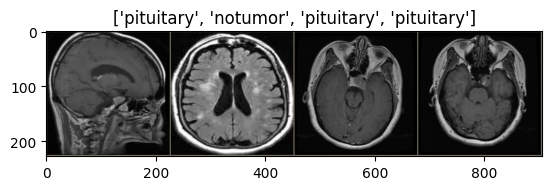

In [ ]:
import torchvision
import numpy as np
import matplotlib.pyplot as plt

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.show()

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes[:4]])

### 3. DenseNet Modelinin Oluşturulması
Transfer learning kullanarak önceden eğitilmiş bir DenseNet121 modelini özelleştiriyoruz.

In [ ]:
def initialize_densenet(num_classes):
    model = models.densenet121(weights='IMAGENET1K_V1')
    # Son katmanı (classifier) kendi sınıf sayımıza göre değiştiriyoruz
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

# 4 sınıf (glioma, meningioma, pituitary, no tumor)
model = initialize_densenet(num_classes=4)
print("DenseNet121 modeli başarıyla yüklendi.")

DenseNet121 modeli başarıyla yüklendi.


### 4. Eğitim Fonksiyonunun Tanımlanması
Modelin eğitim ve doğrulama performansını takip etmek için bir eğitim döngüsü oluşturuyoruz.

In [ ]:
import time
import copy

def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Eğitim tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi doğrulama başarısı: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=15)

Epoch 1/15
----------
train Loss: 0.2466 Acc: 0.9243
val Loss: 0.2498 Acc: 0.9363

Epoch 2/15
----------
train Loss: 0.0748 Acc: 0.9761
val Loss: 0.2497 Acc: 0.9375

Epoch 3/15
----------
train Loss: 0.0340 Acc: 0.9902
val Loss: 0.2069 Acc: 0.9550

Epoch 4/15
----------
train Loss: 0.0296 Acc: 0.9905
val Loss: 0.2524 Acc: 0.9569

Epoch 5/15
----------
train Loss: 0.0232 Acc: 0.9934
val Loss: 0.2601 Acc: 0.9519

Epoch 6/15
----------
train Loss: 0.0168 Acc: 0.9954
val Loss: 0.2209 Acc: 0.9587

Epoch 7/15
----------
train Loss: 0.0061 Acc: 0.9989
val Loss: 0.2659 Acc: 0.9544

Epoch 8/15
----------
train Loss: 0.0074 Acc: 0.9986
val Loss: 0.2742 Acc: 0.9556

Epoch 9/15
----------
train Loss: 0.0053 Acc: 0.9984
val Loss: 0.2816 Acc: 0.9531

Epoch 10/15
----------
train Loss: 0.0058 Acc: 0.9984
val Loss: 0.2591 Acc: 0.9575

Epoch 11/15
----------
train Loss: 0.0042 Acc: 0.9991
val Loss: 0.2834 Acc: 0.9531

Epoch 12/15
----------
train Loss: 0.0052 Acc: 0.9982
val Loss: 0.2725 Acc: 0.9550

E

### 5. Kayıp Fonksiyonu ve Optimizer Belirlenmesi

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Eğitim için kayıp fonksiyonu ve optimizer hazır.")

### 6. Model Performansının Değerlendirilmesi
Eğitilen modelin hangi sınıflarda zorlandığını görmek için karmaşıklık matrisi ve sınıflandırma raporu oluşturuyoruz.

Test Doğruluğu: %95.88

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      glioma       1.00      0.85      0.92       400
  meningioma       0.93      0.99      0.96       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



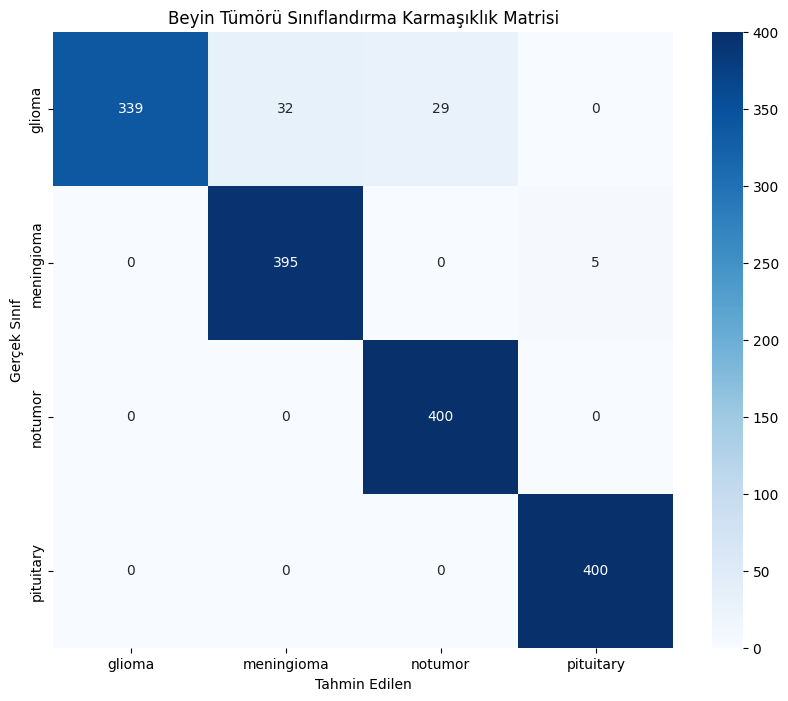

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import torch

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"Test Doğruluğu: %{accuracy_score(all_labels, all_preds)*100:.2f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Sınıf')
    plt.title('Beyin Tümörü Sınıflandırma Karmaşıklık Matrisi')
    plt.show()

evaluate_model(model_ft, dataloaders['val'])

### 9. Test
Görüntü yüklenerek test edilebilir

Saving Te-no_327.jpg to Te-no_327.jpg


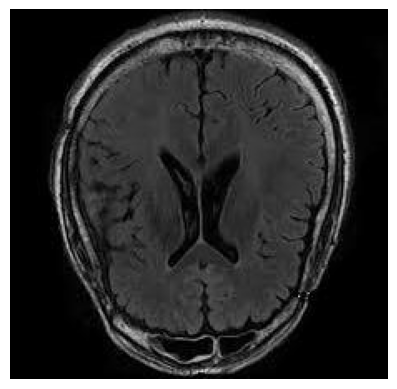

Tahmin: NOTUMOR
Güven Oranı: %99.99


In [ ]:
from google.colab import files
from PIL import Image
import torch.nn.functional as F

def predict_uploaded_image(model, class_names):
    uploaded = files.upload()

    for fn in uploaded.keys():
        img = Image.open(fn).convert('RGB')
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        img_t = data_transforms['val'](img)
        batch_t = torch.unsqueeze(img_t, 0).to(device)

        model.eval()
        with torch.no_grad():
            out = model(batch_t)
            probabilities = F.softmax(out, dim=1)
            conf, preds = torch.max(probabilities, 1)

        result = class_names[preds[0]]
        confidence = conf[0].item() * 100

        print(f"Tahmin: {result.upper()}")
        print(f"Güven Oranı: %{confidence:.2f}")

predict_uploaded_image(model_ft, class_names)